# VGG-19, Resnet-50

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# not important after importing files

# to download 

!pip3 install https://github.com/Martlgap/face-alignment-mtcnn/releases/latest/download/face_alignment_mtcnn-0.3-py3-none-any.whl
!git clone https://github.com/Martlgap/face-alignment-mtcnn.git
%cd /content/face-alignment-mtcnn
%cd /content/face-alignment-mtcnn
!touch fgnet_mtcnn.py
!mkdir cropped_fgnet

In [ ]:
# not important after importing files
# to install tflite for mtcnn face allignment
!echo "deb https://packages.cloud.google.com/apt coral-edgetpu-stable main" | sudo tee /etc/apt/sources.list.d/coral-edgetpu.list
!curl https://packages.cloud.google.com/apt/doc/apt-key.gpg | sudo apt-key add -
!sudo apt-get update
!sudo apt-get install python3-tflite-runtime

In [ ]:
# not important after importing files
# for face cropping and allignment of fgnet dataset
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import facealignment
import os


img_dim = (224, 224)

df = pd.read_csv('/content/face-alignment-mtcnn/new_fgnet.csv', usecols= ['full_path','age'])

for i in range(1002):
  the_path, the_age = df.iloc[i]
  the_split = the_path.split("/")
  the_name = the_split[-1]
  print(the_name)
  final_path = "/" + str(the_path)
  single_face = cv2.imread(final_path)
  tool = facealignment.FaceAlignmentTools()
  # single_face = cv2.cvtColor(single_face, cv2.COLOR_BGR2RGB)

  try:
    aligned_img = tool.align(single_face)
    resized = cv2.resize(aligned_img, img_dim, interpolation = cv2.INTER_AREA)
    save_path = "./cropped_fgnet/" + str(the_name)
    os.chdir('/content/face-alignment-mtcnn/cropped_fgnet/')
    cv2.imwrite(the_name, resized)
    #plt.imshow(resized)
    #plt.axis('off')
    #plt.savefig(save_path, bbox_inches=0)

  except:
    print(i)


In [ ]:
# not important after importing files
# for face cropping and allignment of wiki_imdb dataset
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import facealignment
import os


img_dim = (224, 224)

df = pd.read_csv('/content/face-alignment-mtcnn/wiki.csv', usecols= ['full_path','age'])

for i in range(1002):
  the_path, the_age = df.iloc[i]
  the_split = the_path.split("/")
  the_name = the_split[-1]
  print(the_name)
  final_path = "/" + str(the_path)
  single_face = cv2.imread(final_path)
  tool = facealignment.FaceAlignmentTools()
  # single_face = cv2.cvtColor(single_face, cv2.COLOR_BGR2RGB)

  try:
    aligned_img = tool.align(single_face)
    resized = cv2.resize(aligned_img, img_dim, interpolation = cv2.INTER_AREA)
    save_path = "./cropped_wiki/" + str(the_name)
    os.chdir('/content/face-alignment-mtcnn/cropped_wiki/')
    cv2.imwrite(the_name, resized)
    #plt.imshow(resized)
    #plt.axis('off')
    #plt.savefig(save_path, bbox_inches=0)

  except:
    print(i)


In [ ]:
# not important after loading files
# fgnet age grouping

import pandas as pd


df = pd.read_csv('/content/fgnet.csv')
ages = df['age']
age_group_array = np.zeros(len(ages))

def age_group(age):
    if age >=0 and age <=2:
        return 0
    elif age >2 and age <=5:
        return 1
    elif age >5 and age <=13:
        return 2
    elif age >13 and age <=18:
        return 3
    elif age >18 and age <=24:
        return 4
    elif age >24 and age <=33:
        return 5
    elif age >33 and age <=48:
        return 6
    elif age >48 and age <=64:
        return 7
    else:
        return 8


for i in range(len(ages)):
  the_act_age = ages[i]
  #print(the_act_age)
  final_age_group = age_group(the_act_age)
  age_group_array[i] = final_age_group

as_int = age_group_array.astype(int)
as_string = as_int.astype(str)
df["age_groups"] = as_string
df.to_csv("fgnet_with_age_groups.csv", index=False)

#print(age_group_array)
#print(ages)

In [ ]:
# not important after loading files
# wiki age grouping

import pandas as pd


df = pd.read_csv('/content/wiki.csv')
ages = df['age']
age_group_array = np.zeros(len(ages))

def age_group(age):
    if age >=0 and age <=2:
        return 0
    elif age >2 and age <=5:
        return 1
    elif age >5 and age <=13:
        return 2
    elif age >13 and age <=18:
        return 3
    elif age >18 and age <=24:
        return 4
    elif age >24 and age <=33:
        return 5
    elif age >33 and age <=48:
        return 6
    elif age >48 and age <=64:
        return 7
    else:
        return 8


for i in range(len(ages)):
  the_act_age = ages[i]
  #print(the_act_age)
  final_age_group = age_group(the_act_age)
  age_group_array[i] = final_age_group

as_int = age_group_array.astype(int)
as_string = as_int.astype(str)
df["age_groups"] = as_string
df.to_csv("fgnet_with_age_groups.csv", index=False)

#print(age_group_array)
#print(ages)

In [ ]:
# not important after importing files
# make fgnet csv file

from glob import glob
import pandas as pd
import re

final_labels = []

df = pd.read_csv('/content/fgnet_age__gender_true_label.csv')

# ages = df['age']
full_paths = df['full_path']
age_groups = df['age_groups']
genders = df['gender']


for i in range(len(full_paths)):
  final_string = ''
  gender_string = ''
  if genders[i] == 0:
    gender_string = 'female'
  else:
    gender_string = 'male'
  mid_string = 'age_group: ' + str(age_groups[i]) + ' ' + 'gender: ' + gender_string
  final_string = mid_string
  final_labels.append(final_string)
  

df['final_label'] = final_labels
df.to_csv('fgnet_final_file.csv', columns=['full_path','age', 'age_groups', 'gender','true_label','final_label'], index=False)


In [ ]:
# not important after importing files
# make wiki csv file

from glob import glob
import pandas as pd
import re

final_labels = []

df = pd.read_csv('/content/fgnet_age__gender_true_label.csv')

# ages = df['age']
full_paths = df['full_path']
age_groups = df['age_groups']
genders = df['gender']


for i in range(len(full_paths)):
  final_string = ''
  gender_string = ''
  if genders[i] == 0:
    gender_string = 'female'
  else:
    gender_string = 'male'
  mid_string = 'age_group: ' + str(age_groups[i]) + ' ' + 'gender: ' + gender_string
  final_string = mid_string
  final_labels.append(final_string)
  

df['final_label'] = final_labels
df.to_csv('wiki_final_file.csv', columns=['full_path','age', 'age_groups', 'gender','true_label','final_label'], index=False)


In [ ]:
# copying important files from drive
!cp /content/drive/MyDrive/fgnet_final_file.csv /content/
!cp /content/drive/MyDrive/wiki_final_file.csv /content/
!cp /content/drive/MyDrive/wiki_model.h5 /content/
!cp /content/drive/MyDrive/wiki_final_cropped.zip /content
!unzip /content/wiki_final_cropped.zip
!mv  /content/content/wiki_final_cropped /content
!rm -r /content/content
!cp /content/drive/MyDrive/cropped_fgnet_latest.zip /content
!unzip /content/cropped_fgnet_latest.zip

In [1]:
# wiki data generator for vgg16 model

from keras_preprocessing.image import ImageDataGenerator
import pandas as pd

# datagen=ImageDataGenerator(rescale=1./255.,validation_split=0.25)

train_df = pd.read_csv('/content/wiki_final_file.csv') # for fgnet "/content/fgnet_with_age_groups.csv" 
train_df['final_label'] = train_df['final_label'].astype(str)
# train_df['age_group'] = train_df['age_group'].astype(str)
# train_df['gender'] = train_df['gender'].astype(str)

# y_coll = ['age_group', 'gender']

train_datagen = ImageDataGenerator(
    rescale=1 / 255.0,
    validation_split=0.25
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="full_path",
    y_col="final_label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",  
    subset='training',
    shuffle=True,
    seed=42
)

valid_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="full_path",
    y_col="final_label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset='validation',
    shuffle=True,
    seed=42
)


Found 29256 validated image filenames belonging to 18 classes.
Found 9752 validated image filenames belonging to 18 classes.


In [51]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False ## Not trainable weights
base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [52]:
flatten_layer = layers.Flatten()
dense_layer_1 = layers.Dense(4000, activation='relu')
dense_layer_2 = layers.Dense(200, activation='relu')
dropout = layers.Dropout(0.5)
prediction_layer = layers.Dense(18, activation='softmax')


wiki_model = models.Sequential([
    base_model,
    flatten_layer,
    dense_layer_1,
    dropout,
    dense_layer_2,
    dropout,
    prediction_layer
])

In [53]:
wiki_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense_5 (Dense)             (None, 4000)              100356000 
                                                                 
 dropout_2 (Dropout)         multiple                  0         
                                                                 
 dense_6 (Dense)             (None, 200)               800200    
                                                                 
 dense_7 (Dense)             (None, 18)                3618      
                                                                 
Total params: 115,874,506
Trainable params: 101,159,81

In [54]:
from tensorflow.keras.callbacks import EarlyStopping

wiki_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


es = EarlyStopping(monitor='val_accuracy', mode='max', patience=10,  restore_best_weights=True)

history  = wiki_model.fit(train_generator,
                    validation_data = valid_generator,
                    steps_per_epoch = train_generator.n//train_generator.batch_size,
                    validation_steps = valid_generator.n//valid_generator.batch_size,
                    epochs=20, callbacks=[es])


Epoch 1/20
457/457 [==============================] - 225s 490ms/step - loss: 2.2997 - accuracy: 0.3575 - val_loss: 1.6995 - val_accuracy: 0.4118
Epoch 2/20
457/457 [==============================] - 221s 484ms/step - loss: 1.8279 - accuracy: 0.3925 - val_loss: 1.5910 - val_accuracy: 0.4212
Epoch 3/20
457/457 [==============================] - 221s 484ms/step - loss: 1.6551 - accuracy: 0.4365 - val_loss: 1.4238 - val_accuracy: 0.5041
Epoch 4/20
457/457 [==============================] - 221s 484ms/step - loss: 1.5461 - accuracy: 0.4710 - val_loss: 1.3935 - val_accuracy: 0.5059
Epoch 5/20
457/457 [==============================] - 221s 484ms/step - loss: 1.4736 - accuracy: 0.4877 - val_loss: 1.3785 - val_accuracy: 0.5049
Epoch 6/20
457/457 [==============================] - 221s 483ms/step - loss: 1.4417 - accuracy: 0.4994 - val_loss: 1.3535 - val_accuracy: 0.5251
Epoch 7/20
457/457 [==============================] - 221s 484ms/step - loss: 1.3967 - accuracy: 0.5093 - val_loss: 1.3308 -

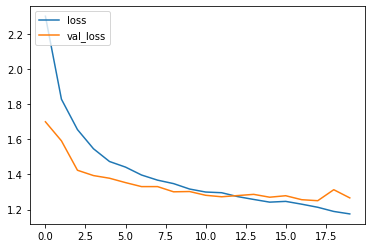

In [55]:
import matplotlib.pyplot as plt
# training loss and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'], loc='upper left')
plt.show()

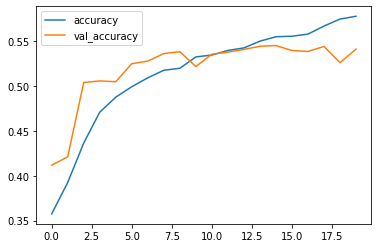

In [56]:
# training accuracy and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'], loc='upper left')
plt.show()

In [2]:
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras import layers, models

base_model = VGG19(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False ## Not trainable weights
base_model.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [3]:
flatten_layer = layers.Flatten()
dense_layer_1 = layers.Dense(4000, activation='relu')
dense_layer_2 = layers.Dense(200, activation='relu')
dropout = layers.Dropout(0.5)
prediction_layer = layers.Dense(18, activation='softmax')


wiki_resnet_model = models.Sequential([
    base_model,
    flatten_layer,
    dense_layer_1,
    dropout,
    dense_layer_2,
    dropout,
    prediction_layer
])

In [9]:
!nvidia-smi

Sat Sep 24 16:07:20 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   73C    P0    34W /  70W |  14544MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [72]:
!pip install numba

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [10]:
from numba import cuda 
device = cuda.get_current_device()
device.reset()

In [4]:
from tensorflow.keras.callbacks import EarlyStopping

wiki_resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)

history  = wiki_resnet_model.fit(train_generator,
                    validation_data = valid_generator,
                    steps_per_epoch = train_generator.n//train_generator.batch_size,
                    validation_steps = valid_generator.n//valid_generator.batch_size,
                    epochs=10, callbacks=[es])







Epoch 1/10
914/914 [==============================] - 272s 292ms/step - loss: 2.6294 - accuracy: 0.3527 - val_loss: 2.2516 - val_accuracy: 0.3589
Epoch 2/10
914/914 [==============================] - 265s 290ms/step - loss: 2.1282 - accuracy: 0.3606 - val_loss: 2.0339 - val_accuracy: 0.3583
Epoch 3/10
914/914 [==============================] - 265s 290ms/step - loss: 2.0013 - accuracy: 0.3609 - val_loss: 1.9686 - val_accuracy: 0.3587
Epoch 4/10
914/914 [==============================] - 266s 291ms/step - loss: 1.9660 - accuracy: 0.3608 - val_loss: 1.9458 - val_accuracy: 0.3580
Epoch 5/10
914/914 [==============================] - 265s 290ms/step - loss: 1.9481 - accuracy: 0.3608 - val_loss: 1.9339 - val_accuracy: 0.3586
Epoch 6/10
914/914 [==============================] - 265s 290ms/step - loss: 1.9436 - accuracy: 0.3608 - val_loss: 1.9276 - val_accuracy: 0.3582


In [ ]:
# save wiki_model
wiki_model.save('./wiki_model.h5')

In [ ]:
# saving model in drive
!cp /content/wiki_model.h5 /content/drive/MyDrive